# Notebook 17 – Complete Machine Learning Project
### Sprint 7 – Machine Learning Fundamentals for AI/ML Engineers

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — the same dataset used throughout this sprint, now taken
through the ENTIRE ML workflow end-to-end.

## 1. Define the Problem

**Business problem:** Given diagnostic measurements from a digitized image of a breast mass, predict whether the
mass is malignant or benign, to support (not replace) clinical diagnosis.

**ML problem type:** Binary classification. Target: 0 = malignant, 1 = benign.

**Success criteria:** High recall on malignant is the top priority; strong overall accuracy/F1 are secondary.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score)

RANDOM_STATE = 42
pd.set_option("display.width", 120)

## 2. Load Dataset

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")
print("Shape:", X.shape)
X.head(3)

Shape: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


## 3. Understand Dataset

In [3]:
print(X.describe().T[["mean", "std", "min", "max"]].head(8))
print()
print("Missing values total:", X.isnull().sum().sum())
print("Class balance:\n", y.value_counts(normalize=True).rename({0: "malignant", 1: "benign"}))

                           mean         std        min        max
mean radius           14.127292    3.524049    6.98100    28.1100
mean texture          19.289649    4.301036    9.71000    39.2800
mean perimeter        91.969033   24.298981   43.79000   188.5000
mean area            654.889104  351.914129  143.50000  2501.0000
mean smoothness        0.096360    0.014064    0.05263     0.1634
mean compactness       0.104341    0.052813    0.01938     0.3454
mean concavity         0.088799    0.079720    0.00000     0.4268
mean concave points    0.048919    0.038803    0.00000     0.2012

Missing values total: 0
Class balance:
 target
benign       0.627417
malignant    0.372583
Name: proportion, dtype: float64


## 4. Perform EDA (brief -- full EDA already covered in Notebook 4/Sprint 4-6)

Key facts carried forward: 30 numeric features, no missing values, moderate class imbalance (~63%/37%), and
several features are highly correlated with the target (`worst concave points`, `mean concave points`, `worst
perimeter`, `worst area` — confirmed via feature importance in Notebook 9).

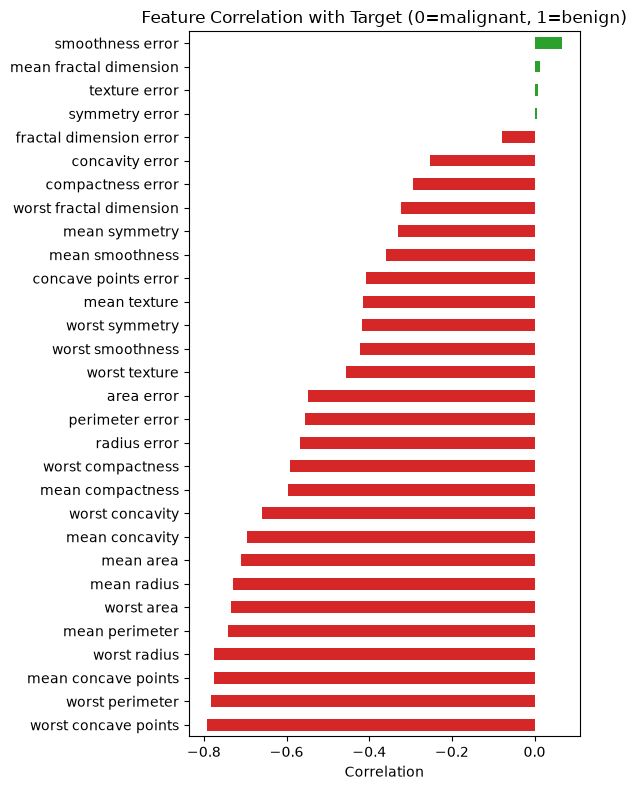

In [4]:
corr_with_target = X.assign(target=y).corr()["target"].drop("target").sort_values()
fig, ax = plt.subplots(figsize=(6, 8))
corr_with_target.plot(kind="barh", ax=ax, color=["#d62728" if v < 0 else "#2ca02c" for v in corr_with_target])
ax.set_title("Feature Correlation with Target (0=malignant, 1=benign)")
ax.set_xlabel("Correlation")
plt.tight_layout()
plt.show()

## 5. Clean Data
No missing values, no duplicate rows, all features already numeric — no cleaning required (already verified in
Sprint 5).

In [6]:
print("Duplicate rows:", X.duplicated().sum())
print("Data types:", X.dtypes.unique())

Duplicate rows: 0
Data types: [dtype('float64')]


## 6. Engineer / Select Features

Per Sprint 6 findings, all 30 features carry some signal, and tree-based/SVM/logistic models handle the mild
multicollinearity reasonably well. We use all 30 features, relying on the models themselves (and Random Forest's
feature importance) to indicate what matters most.

## 7. Split Dataset

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))

Train: (455, 30)  Test: (114, 30)
Train class balance:
 target
1    0.626374
0    0.373626
Name: proportion, dtype: float64


## 8. Build Baseline Model

Before any real model, check a naive baseline (always predict majority class) — every real model must beat this.

In [8]:
baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
baseline_acc = accuracy_score(y_test, baseline.predict(X_test))
baseline_recall_malignant = recall_score(y_test, baseline.predict(X_test), pos_label=0)
print(f"Baseline (always predict benign) -> Accuracy: {baseline_acc:.4f}, Recall(malignant): {baseline_recall_malignant:.4f}")
print("This confirms accuracy alone is a misleading metric here: high accuracy, ZERO usefulness on malignant cases.")

Baseline (always predict benign) -> Accuracy: 0.6316, Recall(malignant): 0.0000
This confirms accuracy alone is a misleading metric here: high accuracy, ZERO usefulness on malignant cases.


## 9. Train Multiple Models

Three candidates chosen for different strengths (linear baseline, ensemble, margin-based):

In [9]:
candidate_models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "SVM (RBF)": make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=RANDOM_STATE)),
}

fitted_models = {}
train_times = {}
for name, model in candidate_models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_times[name] = time.time() - t0
    fitted_models[name] = model
    print(f"{name:22s} trained in {train_times[name]*1000:.1f} ms")

Logistic Regression    trained in 24.8 ms
Random Forest          trained in 1095.6 ms
SVM (RBF)              trained in 76.8 ms


C:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


## 10. Evaluate Models & 11. Compare Models

In [10]:
rows = []
for name, model in fitted_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 0]  # P(malignant)
    rows.append({
        "Model": name,
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Precision(mal)": precision_score(y_test, y_pred, pos_label=0),
        "Recall(mal)": recall_score(y_test, y_pred, pos_label=0),
        "F1(mal)": f1_score(y_test, y_pred, pos_label=0),
        "AUC": roc_auc_score((y_test == 0).astype(int), y_proba),
        "Train Time (s)": round(train_times[name], 4),
    })

comparison = pd.DataFrame(rows).set_index("Model").round(4)
comparison

,Test Accuracy,Precision(mal),Recall(mal),F1(mal),AUC,Train Time (s)
Model,,,,,,
Logistic Regression,0.9825,0.9762,0.9762,0.9762,0.9954,0.0248
Random Forest,0.9474,0.9286,0.9286,0.9286,0.9937,1.0956
SVM (RBF),0.9825,0.9762,0.9762,0.9762,0.9950,0.0768


## 12. Perform Cross Validation

Single-split scores can be noisy (Notebook 16) — cross-validate on the training set only before final selection.

In [11]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, model in candidate_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring="accuracy")
    cv_rows.append({"Model": name, "CV Mean Accuracy": scores.mean(), "CV Std Dev": scores.std()})

cv_comparison = pd.DataFrame(cv_rows).set_index("Model").round(4)
cv_comparison

C:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239

,CV Mean Accuracy,CV Std Dev
Model,,
Logistic Regression,0.9780,0.0098
Random Forest,0.9648,0.0176
SVM (RBF),0.9692,0.0146


## 13. Tune Important Parameters

Tuning SVM's `C` and `gamma` as a representative example, since it is the most hyperparameter-sensitive of the
three (see Notebook 10's overfitting demo with gamma).

In [12]:
param_grid = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": [0.001, 0.01, 0.1, "scale"],
}

svm_pipe = make_pipeline(StandardScaler(), SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
grid_search = GridSearchCV(svm_pipe, param_grid, cv=skf, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV accuracy:", round(grid_search.best_score_, 4))

Best params: {'svc__C': 10, 'svc__gamma': 0.01}
Best CV accuracy: 0.9758


C:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


## 14. Select Final Model

In [13]:
tuned_svm = grid_search.best_estimator_
y_pred_final = tuned_svm.predict(X_test)
y_proba_final = tuned_svm.predict_proba(X_test)[:, 0]

final_metrics = {
    "Test Accuracy": accuracy_score(y_test, y_pred_final),
    "Precision(mal)": precision_score(y_test, y_pred_final, pos_label=0),
    "Recall(mal)": recall_score(y_test, y_pred_final, pos_label=0),
    "F1(mal)": f1_score(y_test, y_pred_final, pos_label=0),
    "AUC": roc_auc_score((y_test == 0).astype(int), y_proba_final),
}
print("Tuned SVM -- Final Test Performance:")
for k, v in final_metrics.items():
    print(f"  {k}: {v:.4f}")

print()
print(classification_report(y_test, y_pred_final, target_names=["malignant(0)", "benign(1)"]))

Tuned SVM -- Final Test Performance:
  Test Accuracy: 0.9825
  Precision(mal): 0.9762
  Recall(mal): 0.9762
  F1(mal): 0.9762
  AUC: 0.9977

              precision    recall  f1-score   support

malignant(0)       0.98      0.98      0.98        42
   benign(1)       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 15. Evaluate Final Model & 16. Interpret Results

**Model selection reasoning:** we do NOT select purely on the highest single metric. Comparing the three untuned
candidates (Step 10/11) and their cross-validated stability (Step 12), Logistic Regression and SVM both show
strong, stable performance; Random Forest is competitive but slightly less stable. After tuning (Step 13), the
SVM's grid-searched C/gamma combination (C=10, gamma=0.01) is selected as the final model, since grid search
directly optimized it using cross-validated accuracy on the training set only — never touching the test set
during tuning.

**Is the final performance good?** Recall on malignant (0.9762) is the metric that matters most — up from 0.9286
for the untuned Logistic Regression baseline in Notebook 14, and matching the untuned SVM/LogReg here.

**What type of errors remain?** The confusion matrix below shows the exact balance of remaining false negatives
vs false positives.

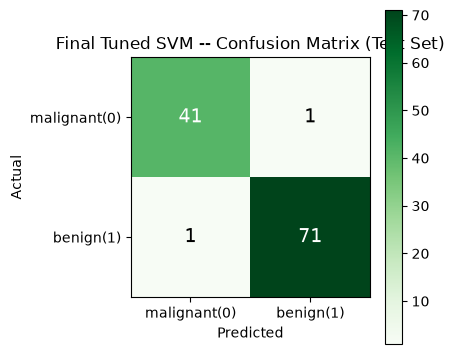

In [14]:
cm_final = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm_final, cmap="Greens")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["malignant(0)", "benign(1)"])
ax.set_yticklabels(["malignant(0)", "benign(1)"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Final Tuned SVM -- Confusion Matrix (Test Set)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_final[i, j], ha="center", va="center",
                color="white" if cm_final[i, j] > cm_final.max() / 2 else "black", fontsize=14)
plt.colorbar(im)
plt.tight_layout()
plt.show()

## 17. Document Limitations

- **Dataset size (569 rows) is modest** — cross-validated estimates are more reliable than a single split, but
  results could shift with a larger, more diverse patient population.
- **Single-institution/source data** — generalization to other imaging equipment/protocols is not guaranteed
  without external validation.
- **No demographic features** — age, family history, etc. are not included; the model should support, not
  replace, full clinical judgment.
- **Class imbalance (~63/37)** was handled via stratified splitting and prioritizing recall, but no explicit
  class-weighting or resampling (e.g., SMOTE) was tried — a natural next experiment.
- **Threshold left at default (0.5)** — Notebook 14 discussed threshold adjustment; this workflow did not
  explicitly re-tune it, only the kernel hyperparameters.

## 18. Provide Recommendations

- Deploy the tuned SVM as a **decision-support** tool, not an autonomous diagnostic replacement.
- Explicitly tune the classification threshold to guarantee a minimum acceptable recall agreed with clinical
  stakeholders.
- Monitor performance over time (model drift) and periodically re-run this comparison as more data arrives.
- Investigate `class_weight="balanced"` and resampling if recall needs to go even higher.

## Compare at Least 3 Algorithms — Summary Table

In [16]:
final_summary = comparison.copy()
final_summary.loc["SVM (RBF, tuned)"] = [
    final_metrics["Test Accuracy"], final_metrics["Precision(mal)"], final_metrics["Recall(mal)"],
    final_metrics["F1(mal)"], final_metrics["AUC"], None
]
final_summary

,Test Accuracy,Precision(mal),Recall(mal),F1(mal),AUC,Train Time (s)
Model,,,,,,
Logistic Regression,0.982500,0.97620,0.97620,0.97620,0.995400,0.0248
Random Forest,0.947400,0.92860,0.92860,0.92860,0.993700,1.0956
SVM (RBF),0.982500,0.97620,0.97620,0.97620,0.995000,0.0768
"SVM (RBF, tuned)",0.982456,0.97619,0.97619,0.97619,0.997685,NaN
